## Evaluate Tuning Results Based on Validation Data Set

to create Figure B1 and Table B1

In [ ]:
import os
import json
import sys

import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import xarray as xr

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'evaluations')[0]

sys.path.append(os.path.sep.join([base_dir , 'src']))
from help_fcts import get_rmse, get_mae, get_mbe, get_r2


MODE = 'val'  # use validation set!

In [2]:
scaling_factor = 1.796553703424 / 58391    # scaling_factor from mm w.e. to Gt for Greenland (specific to HIRHAM5 domain)
data_dir = os.path.sep.join([base_dir, 'data', 'processed', 'HIRHAM5-ERAInterim', 'v_02'])

train_test_split_file = 'train_val_test_split_100.json'
train_val_test_indices = json.load(open(os.path.sep.join([data_dir, train_test_split_file])))
valtest_indices = train_val_test_indices[MODE]

### Load Climatology (1990-2013) as baseline

In [3]:
interim_dir = os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack'])
clim_melt = xr.open_dataset(os.path.sep.join([interim_dir, 'climat_1990-2013_smoothed15.nc']))['snmel']
clim_melt_z = clim_melt.stack(z=('x', 'y')).reset_index('z').dropna('z', how='any')

In [4]:
# load base dataset
data_dir = os.path.sep.join([base_dir, 'data', 'processed', 'HIRHAM5-ERAInterim', 'v_02'])
ds = xr.open_zarr(os.path.sep.join([data_dir, f'base_dataset.zarr']), chunks='auto')
ds = ds.sel(time=valtest_indices)
ds_melt_z = ds['snmel']
ds_melt = ds_melt_z.set_index(z=['y', 'x']).unstack('z')

In [5]:
# Calculate daily anomalies of true validation data w.r.t. the climatology
md_clim = clim_melt_z['time'].dt.strftime('%m-%d')
clim_melt_z = clim_melt_z.assign_coords(md=md_clim)
clim_by_md = clim_melt_z.groupby('md').mean(dim='time')
md_data = ds_melt_z['time'].dt.strftime('%m-%d')
ds_melt_z = ds_melt_z.assign_coords(md=('time', md_data.values))
anomaly = clim_by_md - ds_melt_z.groupby('md')
anoms_val_z = anomaly.compute()
anoms_val = anoms_val_z.set_index(z=['y', 'x']).unstack('z')

### Performance of Climatology as Model

In [6]:
# climatological anomaly per location of valdiation
print(f'GrIS:')
gris_scores = {'rmse': get_rmse(anoms_val_z, 2),
               'mae': get_mae(anoms_val_z, 2),
               'mbe': get_mbe(anoms_val_z, 4)}
               
print(f'RMSE: {gris_scores["rmse"]}')
print(f'MAE: {gris_scores["mae"]}')
print(f'MBE: {gris_scores["mbe"]}')

GrIS:
RMSE: 2.22
MAE: 0.53
MBE: -0.0529


## Compare all tuning trials

In [7]:
# for each set-up need mae_rate+mbe_rate (i.e. sum of MAE and MBE relative to MAE and MBE from climatolgy) 
out_dir = os.path.sep.join([base_dir, 'output'])

configs = ['regression', 'modularNN', 'shorttermNN', 'autoreg1noise', 
           'modularNN_multitarget', 'modularNN_multitarget_trainable']
scores_overview = {}

# # make files with relative scores
# for modelname in configs:
#     if modelname == 'autoreg1noise':
#         inf_values = ['', '_auto']  # '' refers to teacher-forced, '_auto' to inference mode
#     else:
#         inf_values = ['']
#     for inf in inf_values:
#         model_dir = os.path.sep.join([out_dir, f'optuna_melt_{modelname}'])
#         scores_modular = pd.read_csv(os.path.sep.join([model_dir, f'scores{inf}_{MODE}.csv']))
#         scores_modular['rmse_rate'] = scores_modular['rmse'] / gris_scores["rmse"]
#         scores_modular['mae_rate'] = scores_modular['mae'] / gris_scores["mae"]
#         scores_modular['mbe_rate'] = scores_modular['mbe'] / np.abs(gris_scores["mbe"])
#         scores_modular['mae+mbe_rate'] = np.abs(scores_modular['mae_rate']) + np.abs(scores_modular['mbe_rate'])
#         scores_modular.sort_values('mae+mbe_rate', inplace=True)
#         save_dir = os.path.sep.join([model_dir, f'score_rates{inf}_'+MODE+'.csv'])
#         print(f'Saving scores rates to {save_dir}')
#         scores_modular.to_csv(save_dir, index=False)
#         scores_overview[f'{modelname}{inf}'] = scores_modular


# read the overview files
for modelname in configs:
    if modelname == 'autoreg1noise':
        inf_values = ['', '_auto']
    else:
        inf_values = ['']
    for inf in inf_values:
        model_dir = os.path.sep.join([out_dir, f'optuna_melt_{modelname}'])
        scores_overview[f'{modelname}{inf}'] = pd.read_csv(os.path.sep.join([model_dir, f'score_rates{inf}_{MODE}.csv']), index_col=0)
        print(f'Best models for config: {modelname}{inf}')
        display(scores_overview[f'{modelname}{inf}'].head())

Best models for config: regression


,rmse,mae,mbe,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,
0,1.477741,0.341831,0.052677,0.665649,0.644964,0.995784,1.640748
4,1.467088,0.353441,0.056629,0.660850,0.666870,1.070486,1.737356
5,1.469800,0.356014,0.062701,0.662072,0.671724,1.185267,1.856991
1,1.468925,0.347256,0.064844,0.661678,0.655201,1.225785,1.880985
2,1.494749,0.365251,0.067964,0.673310,0.689153,1.284758,1.973910


Best models for config: modularNN


,rmse,mae,mbe,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,
21,0.857585,0.155213,0.001532,0.386299,0.292855,0.028968,0.321823
6,0.858485,0.162048,0.001877,0.386705,0.305751,0.035491,0.341241
41,0.854369,0.150285,-0.003370,0.384851,0.283556,-0.063706,0.347262
35,0.843150,0.156256,0.003145,0.379797,0.294822,0.059446,0.354268
3,0.851017,0.158443,0.004464,0.383341,0.298948,0.084392,0.383341


Best models for config: shorttermNN


...

,rmse,mae,mbe,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,
18,0.863836,0.136568,0.000056,0.389115,0.257676,0.001068,0.258743
9,0.869981,0.127200,-0.001725,0.391883,0.240000,-0.032616,0.272616
7,0.847242,0.119344,-0.002670,0.381641,0.225177,-0.050478,0.275655
11,0.826689,0.125553,0.004283,0.372382,0.236893,0.080963,0.317857
21,0.872338,0.129626,0.004160,0.392945,0.244576,0.078635,0.323211


Best models for config: modularNN_multitarget


,rmse,mae,mbe,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,
18,0.857470,0.154932,0.001931,0.386248,0.292325,0.036510,0.328835
8,0.857870,0.167115,-0.001199,0.386428,0.315312,-0.022675,0.337986
10,0.850256,0.155907,0.002381,0.382998,0.294163,0.045006,0.339169
22,0.848668,0.151348,-0.003137,0.382283,0.285562,-0.059300,0.344862
0,0.865534,0.161947,0.002631,0.389880,0.305560,0.049738,0.355297


Best models for config: modularNN_multitarget_trainable


,rmse,mae,mbe,rmse_rate,mae_rate,mbe_rate,mae+mbe_rate
trial,,,,,,,
23,0.842324,0.151584,0.001143,0.379425,0.286007,0.021614,0.307621
1,0.868842,0.163397,-0.000397,0.391370,0.308297,-0.007500,0.315797
31,0.852349,0.161989,-0.001585,0.383941,0.305640,-0.029963,0.335603
17,0.869760,0.161741,-0.002648,0.391784,0.305172,-0.050059,0.355231
19,0.869747,0.169822,0.003747,0.391778,0.320419,0.070832,0.391251


## Tuning Evaluation

Best Regression NN: trial 0 with MAE=0.3418308351255243, MBE=0.0526769771855031
Best Modular NN: trial 21 with MAE=0.1552133462035758, MBE=0.0015323939151699
Best Short-term NN: trial 28 with MAE=0.2224381601515297, MBE=-0.0008041217723275
Best Autoreg NN (teacher): trial 19 with MAE=0.0572420925186628, MBE=-0.0006145100886095
Best Autoreg NN (inference): trial 18 with MAE=0.136568054926026, MBE=5.647650613956333e-05


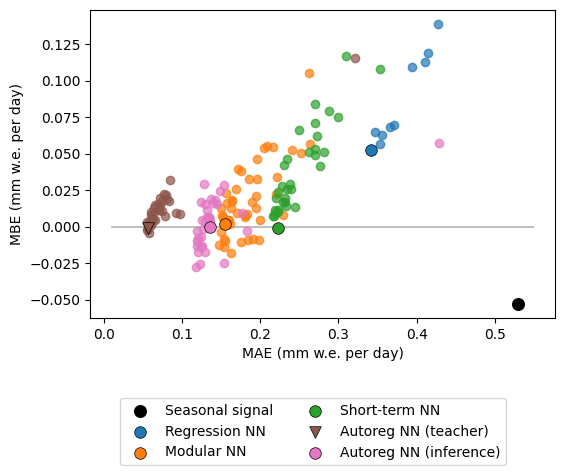

In [ ]:
# Figure B1: Scatter plot of MAE vs MBE for all tuning trials of model configurations
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = [cmap.colors[i] for i in [0, 1, 2, 5, 6, 7]]

plot_configs = {'regression':'Regression NN', 
                'modularNN':'Modular NN', 
                'shorttermNN': 'Short-term NN', 
                'autoreg1noise': 'Autoreg NN (teacher)', 
                'autoreg1noise_auto': 'Autoreg NN (inference)'}

fig, ax = plt.subplots(figsize=(6,4))
ax.hlines(0, .01, .55,color='silver', zorder=0)
ax.scatter(gris_scores['mae'], gris_scores['mbe'], label='Seasonal signal', marker='o', color='k', s=70)

for i, (model, label) in enumerate(plot_configs.items()):
    df = scores_overview[model]
    df = df[df['mae']<0.6]  # add extra filtering, since there are two very bad tuning trials for modular NN
    ax.scatter(df['mae'], df['mbe'], marker='o', alpha=0.7, color=colors[i])
    df_best = df.loc[df['mae+mbe_rate'].idxmin()]
    print(f'Best {label}: trial {df_best.name} with MAE={df_best["mae"]}, MBE={df_best["mbe"]}')
    marker='v' if 'teacher' in label else 'o'
    ax.scatter(df_best['mae'], df_best['mbe'], label=label, marker=marker, edgecolor='k', linewidth=.5, color=colors[i], s=70)

ax.set_xlabel('MAE (mm w.e. per day)')
ax.set_ylabel('MBE (mm w.e. per day)')
plt.legend(ncols=2, bbox_to_anchor=(0.05, -.5), loc='lower left')

#fig.savefig(os.path.sep.join([base_dir, 'figures', 'tuning_scores.png']), bbox_inches='tight', dpi=300)
plt.show()